In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import utils.UVA as UVA
import utils.MVA as MVA
import utils.PCA as PCA

from sklearn.preprocessing import OneHotEncoder, StandardScaler, StandardScaler
#from sklearn.decomposition import PCA

from sklearn.cluster import KMeans, DBSCAN
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, silhouette_samples

#from yellowbrick.cluster import KElbowVisualizer

In [2]:
# pip install threadpoolctl==3.1.0

In [3]:
#import warnings
#warnings.filterwarnings("ignore")

In [4]:
pwd

'\\\\wsl.localhost\\Ubuntu\\home\\dgaillot\\code\\openclassrooms\\openclassrooms\\projets\\projet_5'

In [5]:
#df = pd.read_csv('data/olist_rfm.csv')

df = pd.read_csv('data/clean_df_customers.csv')

In [6]:
df.head()

,recency,auto,bed_bath_table,computers_accessories,garden_tools,health_beauty,housewares,watches_gifts,other_categories,freight_value,frequency_light,frequency_medium,frequency_heavy,sellers_count,mean_pay_installments
0,380,0.0,0.0,0.0,0.0,0.0,29.99,0.0,0.0,17.44,1,1,0,2,1.0
1,85,0.0,0.0,0.0,0.0,0.0,0.00,0.0,118.7,22.76,1,0,0,1,1.0
2,70,159.9,0.0,0.0,0.0,0.0,0.00,0.0,0.0,19.22,0,1,0,1,3.0
3,333,0.0,0.0,0.0,0.0,0.0,0.00,0.0,45.0,27.20,0,1,0,1,1.0
4,246,0.0,0.0,0.0,0.0,0.0,0.00,0.0,19.9,8.72,1,0,0,1,1.0


In [7]:
# remove customer_unique_id
#df.drop(['customer_unique_id'], axis=1, inplace=True)
#df.head()

In [8]:
df.shape

(95399, 15)

In [9]:
df.dtypes

recency                    int64
auto                     float64
bed_bath_table           float64
computers_accessories    float64
garden_tools             float64
health_beauty            float64
housewares               float64
watches_gifts            float64
other_categories         float64
freight_value            float64
frequency_light            int64
frequency_medium           int64
frequency_heavy            int64
sellers_count              int64
mean_pay_installments    float64
dtype: object

In [10]:
df.isna().sum()

recency                  0
auto                     0
bed_bath_table           0
computers_accessories    0
garden_tools             0
health_beauty            0
housewares               0
watches_gifts            0
other_categories         0
freight_value            0
frequency_light          0
frequency_medium         0
frequency_heavy          0
sellers_count            0
mean_pay_installments    0
dtype: int64

In [11]:
quantiles = df.quantile(q=[0.25,0.5,0.75])
quantiles

,recency,auto,bed_bath_table,computers_accessories,garden_tools,health_beauty,housewares,watches_gifts,other_categories,freight_value,frequency_light,frequency_medium,frequency_heavy,sellers_count,mean_pay_installments
0.25,163.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,14.08,0.0,0.0,0.0,1.0,1.0
0.50,268.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,17.60,0.0,0.0,0.0,1.0,2.0
0.75,397.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,56.99,25.54,1.0,1.0,1.0,1.0,4.0


# Distribution

In [12]:
num_cols = df.select_dtypes(include=np.number).columns.to_list()
num_cols

['recency',
 'auto',
 'bed_bath_table',
 'computers_accessories',
 'garden_tools',
 'health_beauty',
 'housewares',
 'watches_gifts',
 'other_categories',
 'freight_value',
 'frequency_light',
 'frequency_medium',
 'frequency_heavy',
 'sellers_count',
 'mean_pay_installments']

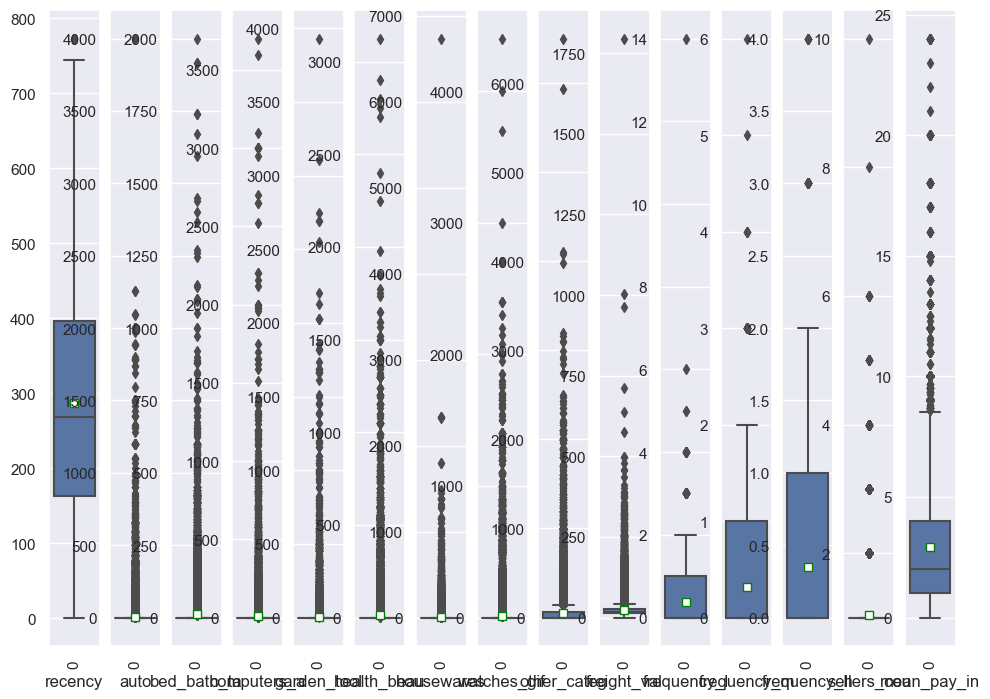

In [13]:
MVA.boxplot_nums(df, num_cols)

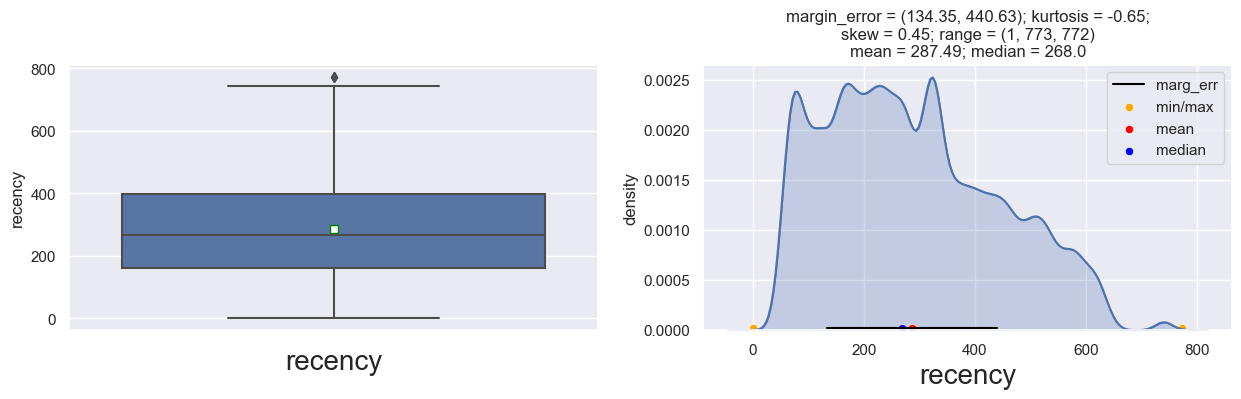

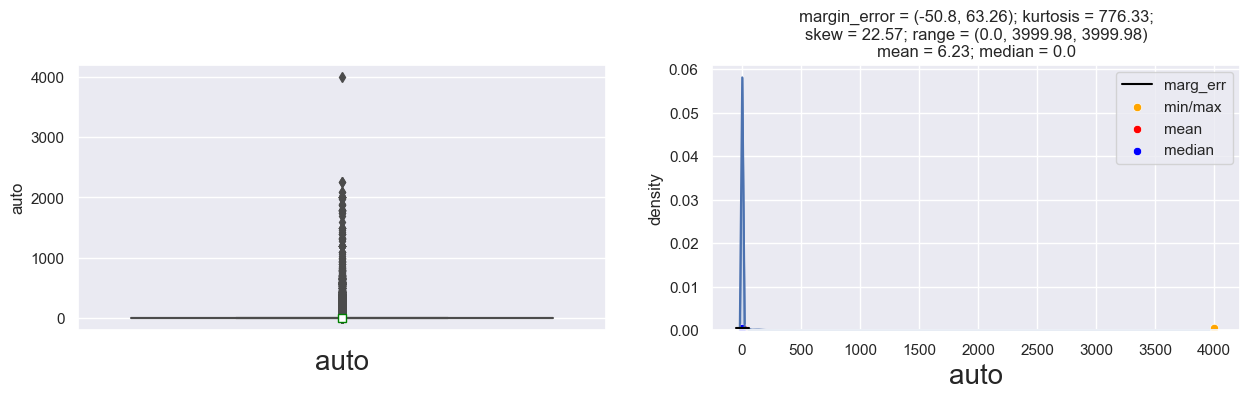

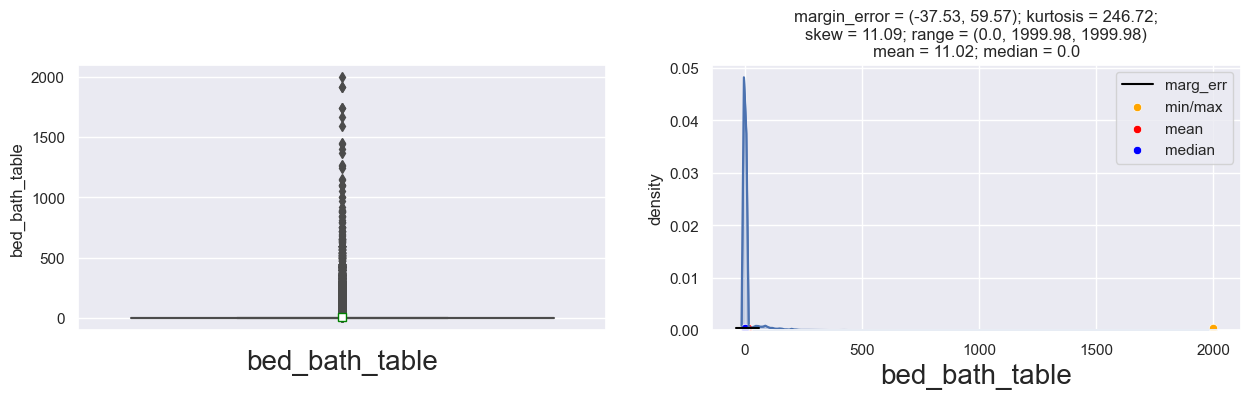

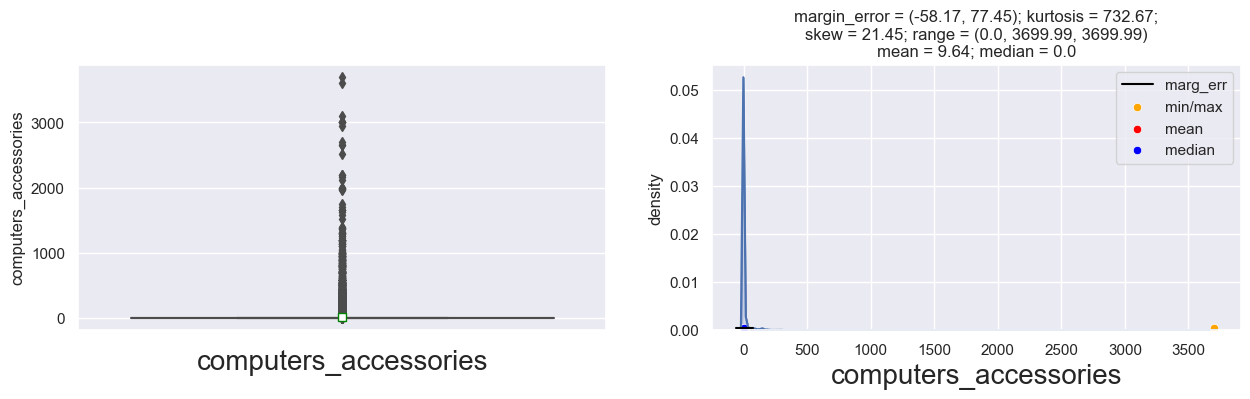

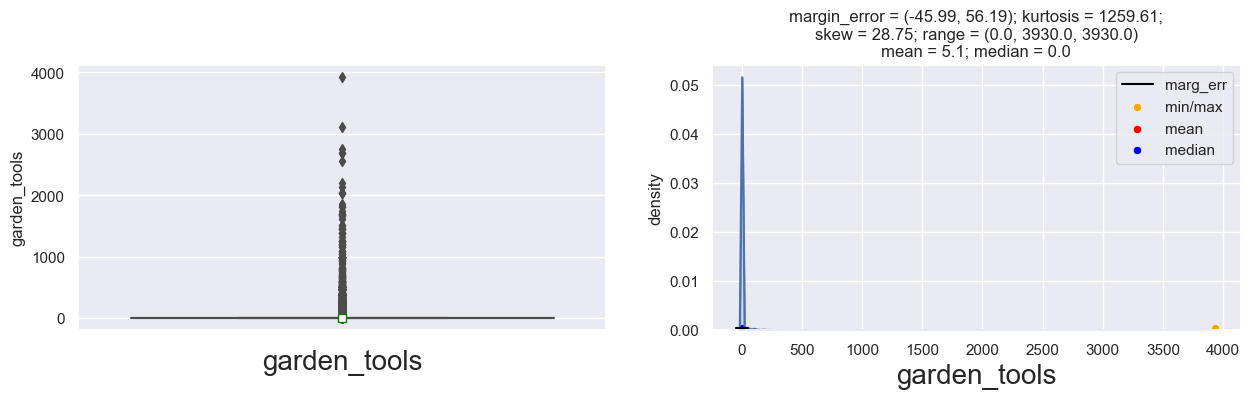

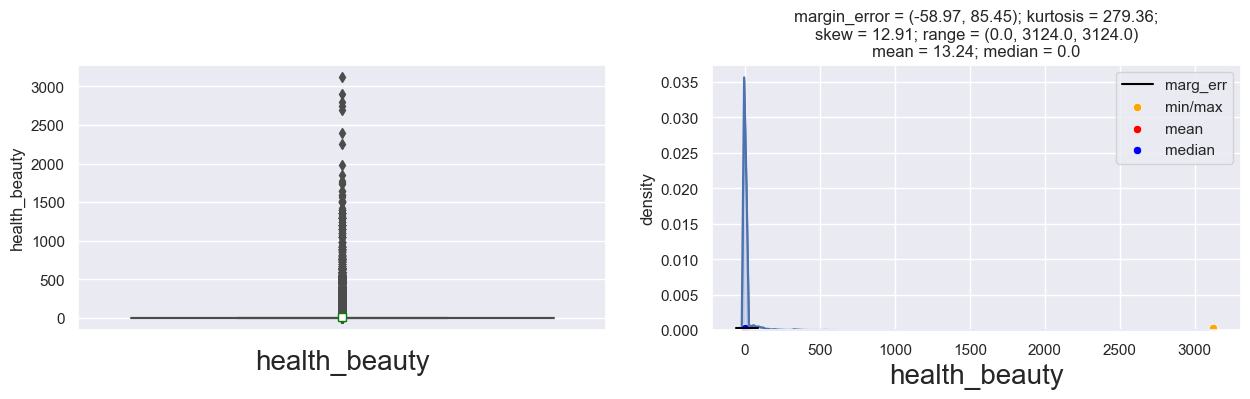

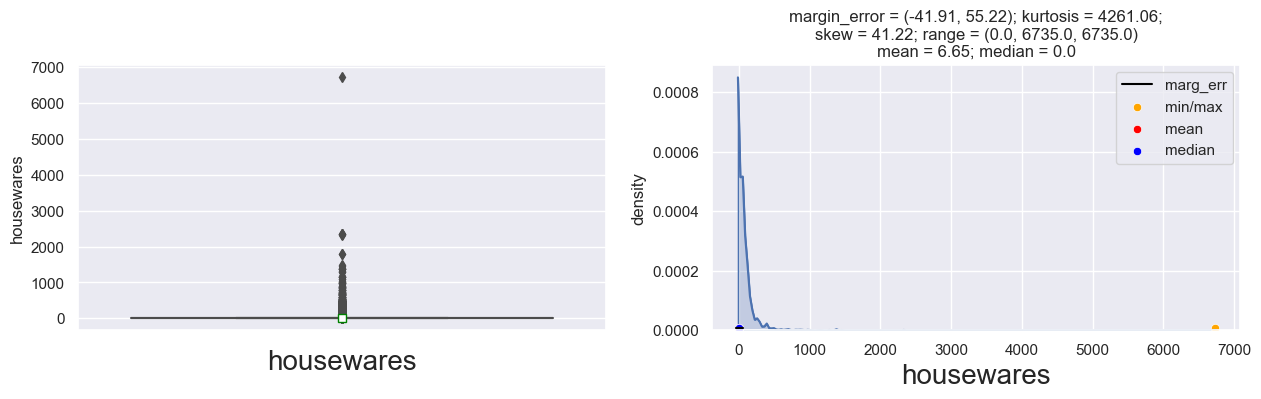

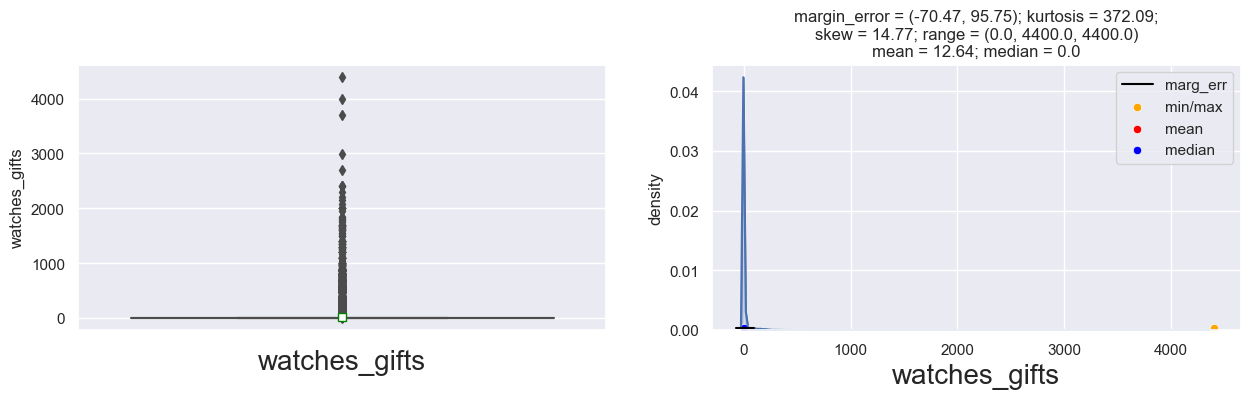

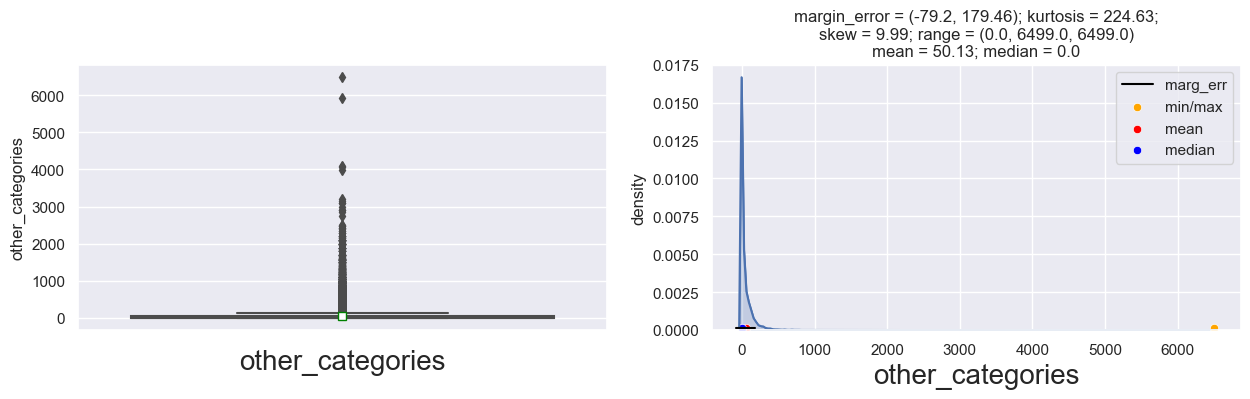

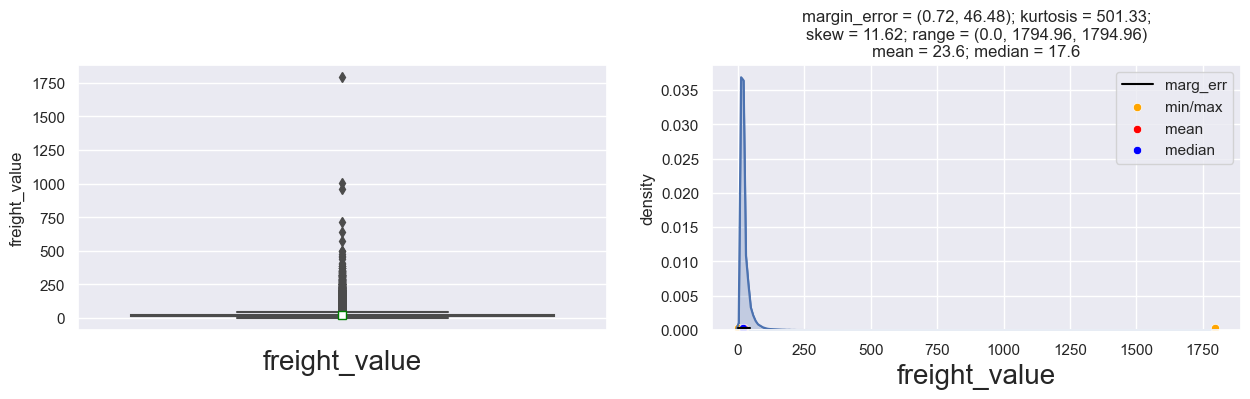

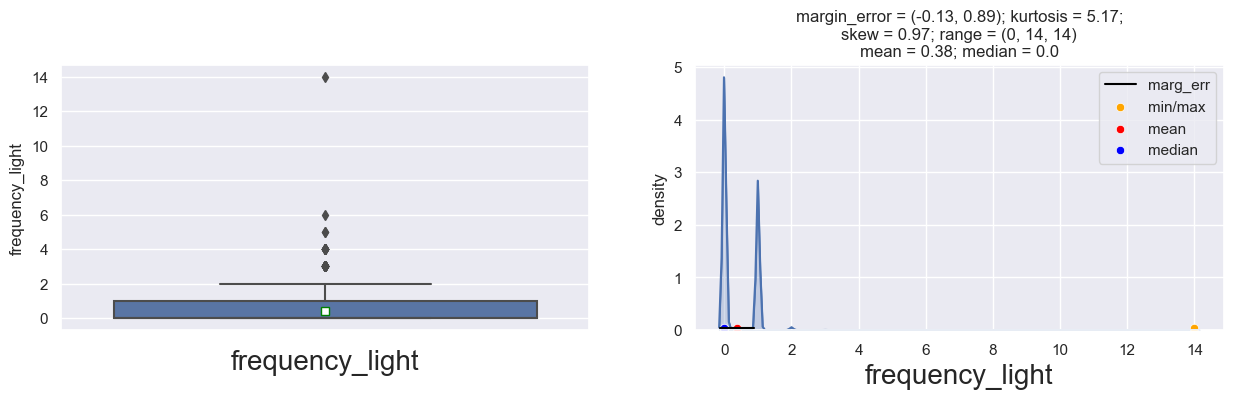

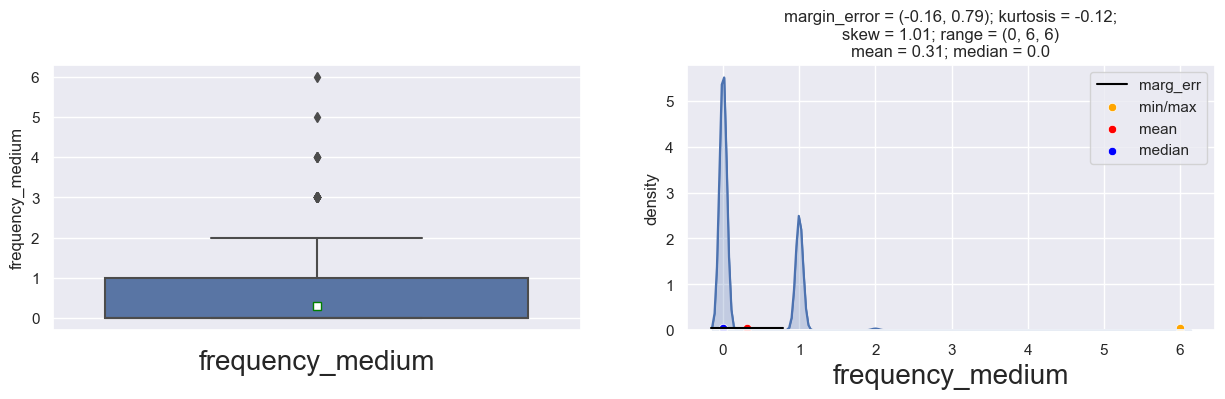

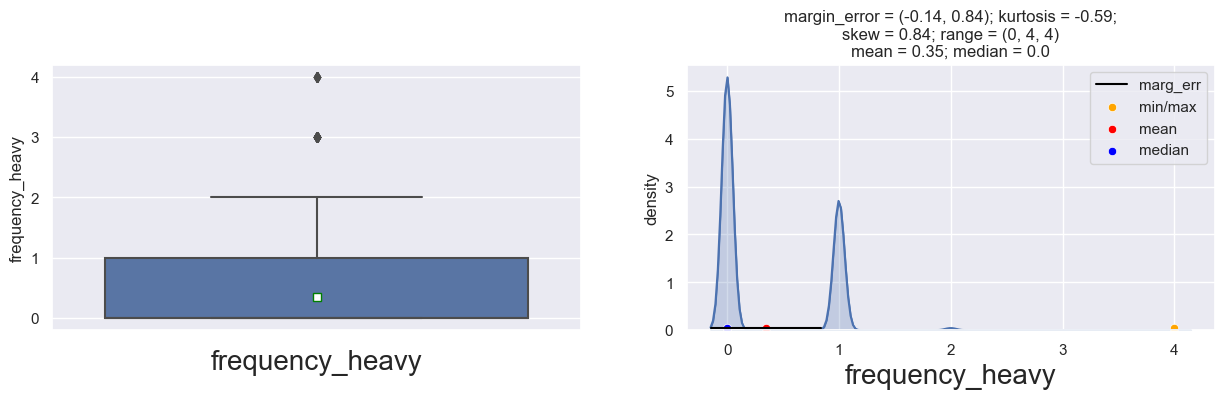

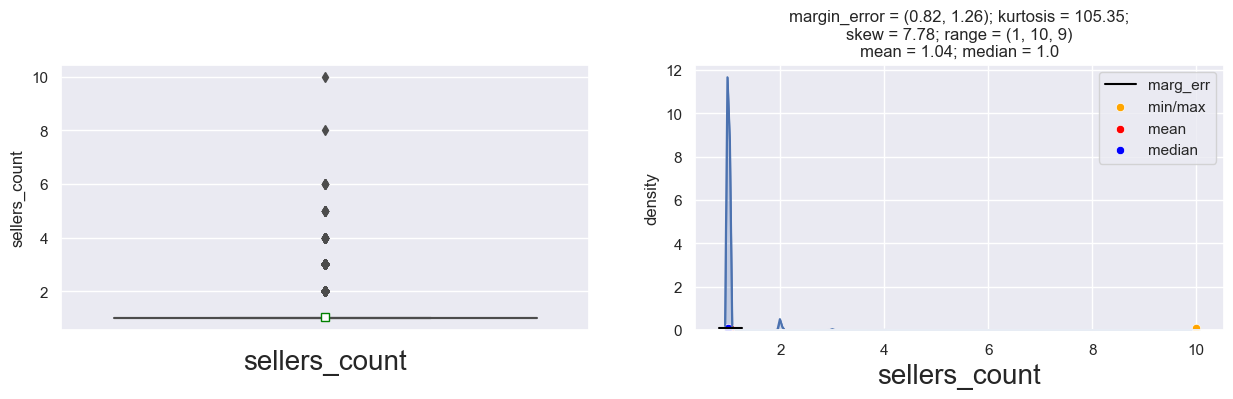

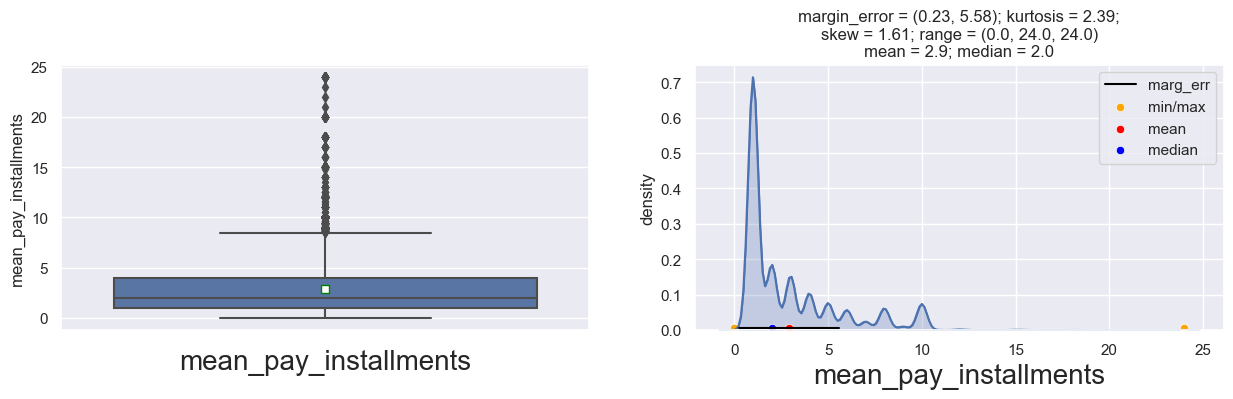

In [14]:
UVA.num_plus(df, num_cols)

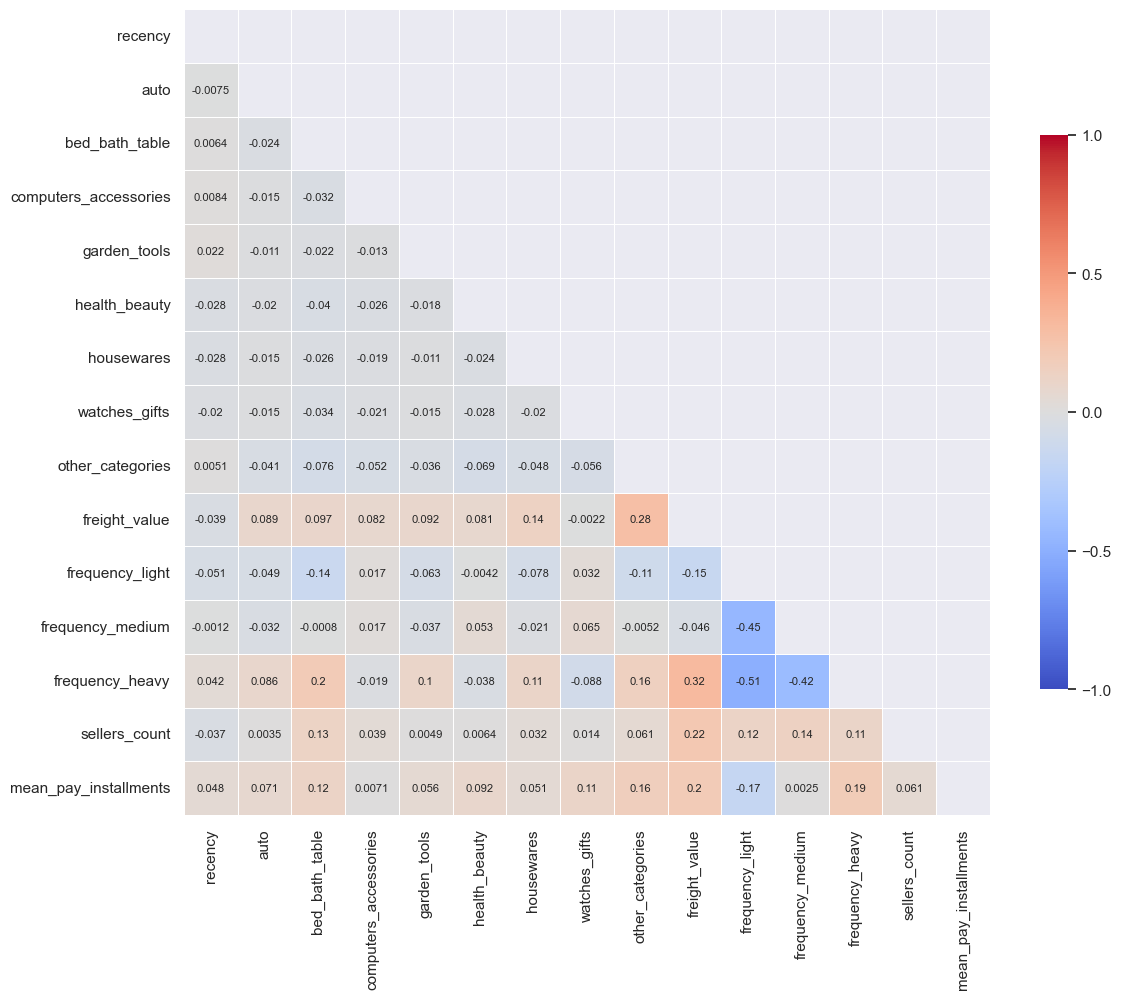

In [15]:
MVA.heatmap_num_2(df, annot_val=True, textsize=8) #

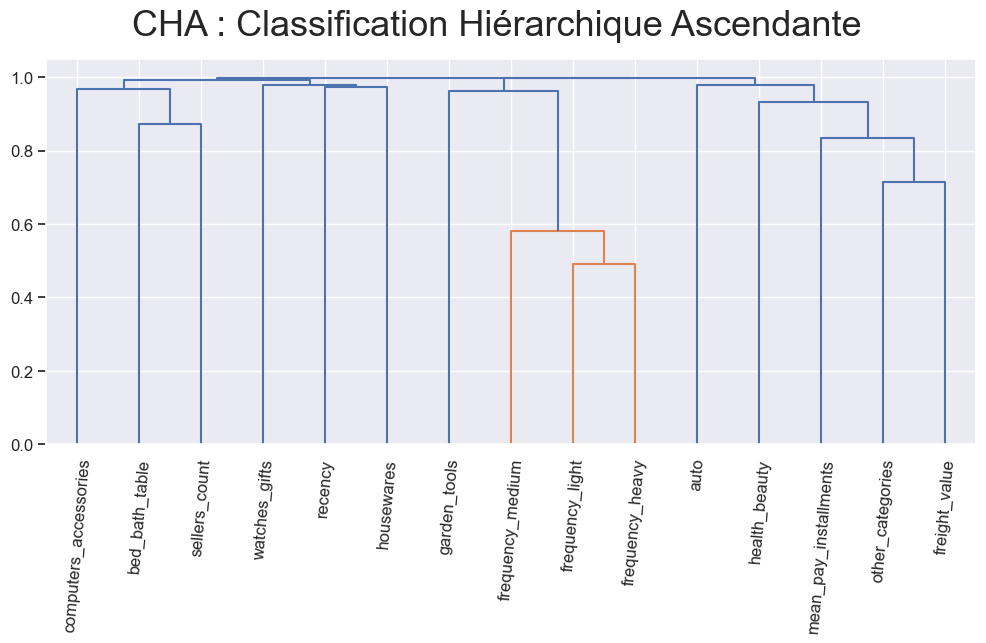

In [16]:
PCA.CHA(df, num_cols, label_size=12, rotation=85)

# Echantillon

In [17]:
df_redux = df.sample(10000, random_state=1).copy()
X = df_redux.copy()
#categorical_columns = X.select_dtypes(['category','object']).columns
num_cols = X.select_dtypes(include=np.number).columns.to_list()

ss = StandardScaler()
X[num_cols] = ss.fit_transform(X[num_cols])

### X_std / echantillon

In [18]:
X_std = PCA.clean_data(df, num_cols, impute=False, std=True)

	>>> Selected features: ['recency', 'auto', 'bed_bath_table', 'computers_accessories', 'garden_tools', 'health_beauty', 'housewares', 'watches_gifts', 'other_categories', 'freight_value', 'frequency_light', 'frequency_medium', 'frequency_heavy', 'sellers_count', 'mean_pay_installments']
	>>> Standardized data


In [19]:
X_std

,recency,auto,bed_bath_table,computers_accessories,garden_tools,health_beauty,housewares,watches_gifts,other_categories,freight_value,frequency_light,frequency_medium,frequency_heavy,sellers_count,mean_pay_installments
0,0.604081,-0.109247,-0.226909,-0.142170,-0.099809,-0.183339,0.480574,-0.152115,-0.387629,-0.269261,1.220451,1.440315,-0.711205,4.432184,-0.710769
1,-1.322254,-0.109247,-0.226909,-0.142170,-0.099809,-0.183339,-0.136963,-0.152115,0.530175,-0.036748,1.220451,-0.658266,-0.711205,-0.175118,-0.710769
2,-1.420203,2.694563,-0.226909,-0.142170,-0.099809,-0.183339,-0.136963,-0.152115,-0.387629,-0.191465,-0.752066,1.440315,-0.711205,-0.175118,0.036052
3,0.297174,-0.109247,-0.226909,-0.142170,-0.099809,-0.183339,-0.136963,-0.152115,-0.039683,0.157305,-0.752066,1.440315,-0.711205,-0.175118,-0.710769
4,-0.270932,-0.109247,-0.226909,-0.142170,-0.099809,-0.183339,-0.136963,-0.152115,-0.233760,-0.650373,1.220451,-0.658266,-0.711205,-0.175118,-0.710769
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95394,1.955780,-0.109247,-0.226909,-0.142170,-0.099809,0.813732,-0.136963,-0.152115,-0.387629,-0.459817,-0.752066,1.440315,-0.711205,-0.175118,0.036052
95395,-0.225222,-0.109247,-0.226909,-0.142170,-0.099809,-0.183339,-0.136963,-0.152115,-0.387629,-0.153005,-0.752066,-0.658266,1.324691,-0.175118,0.036052
95396,0.839159,-0.109247,-0.226909,-0.142170,-0.099809,-0.183339,-0.136963,-0.152115,1.205112,1.810248,-0.752066,-0.658266,1.324691,-0.175118,0.782873
95397,-0.035854,-0.109247,-0.226909,5.166825,-0.099809,-0.183339,-0.136963,-0.152115,-0.387629,2.516530,-0.752066,-0.658266,1.324691,-0.175118,0.409463


# PCA

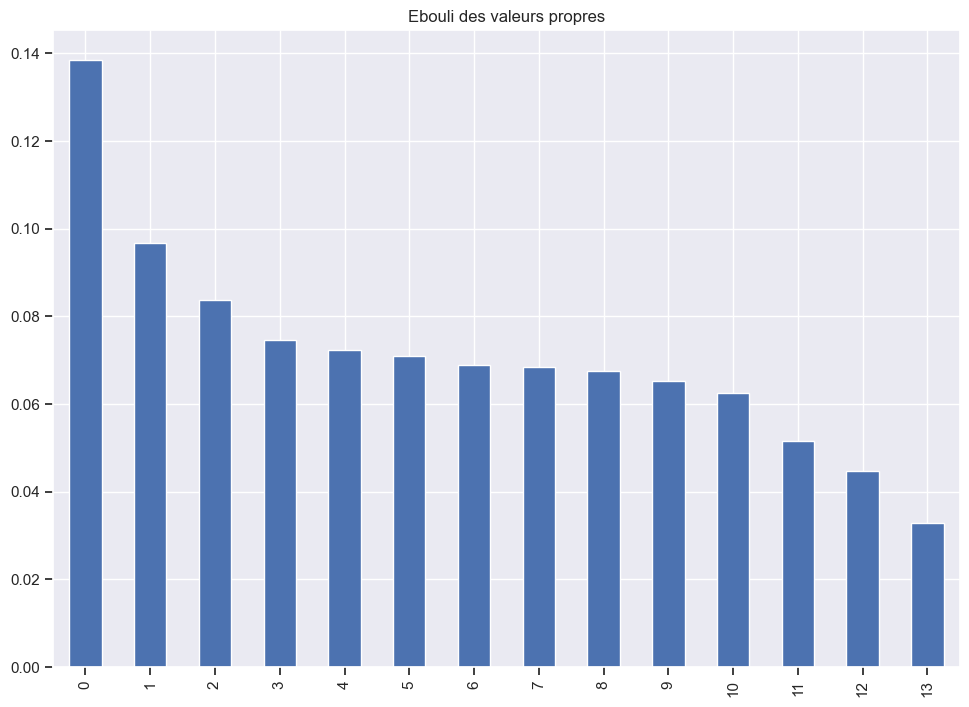

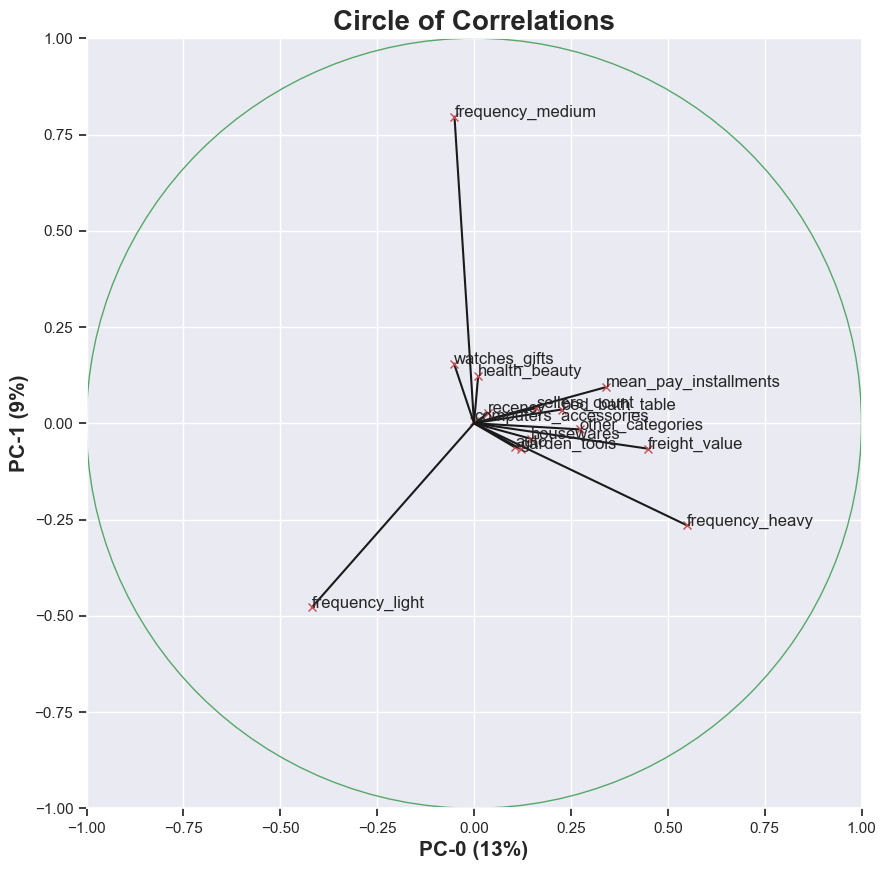

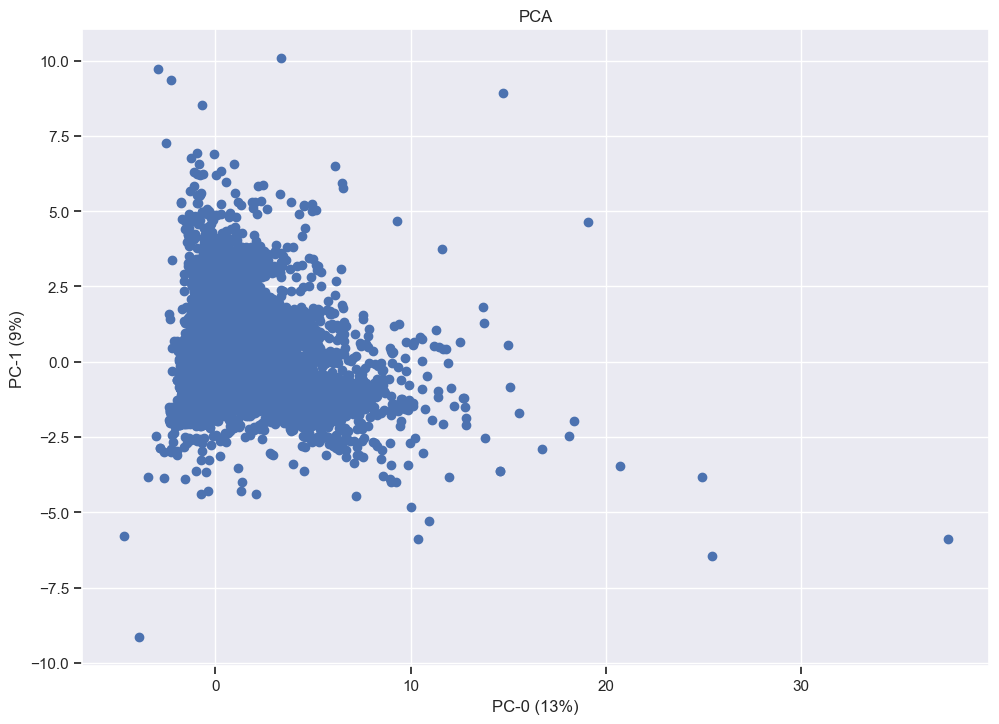

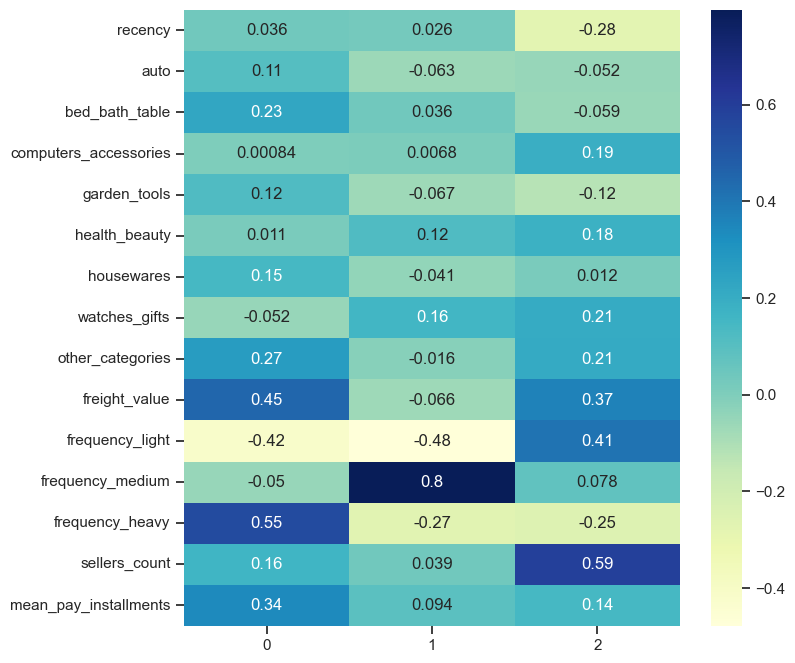

Résumé PCA
Total: 14 composants
----------------------------------------
Moyenne de la variance expliquée : 0.071
----------------------------------------
    explained variance  cumulative
1             0.138420    0.138420
2             0.096634    0.235054
3             0.083655    0.318710
4             0.074630    0.393340
5             0.072237    0.465577
6             0.070909    0.536486
7             0.068990    0.605476
8             0.068443    0.673919
9             0.067467    0.741386
10            0.065261    0.806647
11            0.062438    0.869085
12            0.051442    0.920527
13            0.044605    0.965132
14            0.032853    0.997985
----------------------------------------


,PC-0,PC-1,PC-2,PC-3,PC-4,PC-5,PC-6,PC-7,PC-8,PC-9,PC-10,PC-11,PC-12,PC-13
recency,0.036260,0.025764,-0.276153,0.097891,0.023319,-0.421883,0.362225,-0.062553,-0.055919,-0.411409,0.623735,-0.144867,0.126899,-0.000444
auto,0.106003,-0.062694,-0.052042,0.027193,0.287205,0.180885,0.093484,0.113242,0.799866,0.267715,0.279028,0.055990,0.097843,-0.206375
bed_bath_table,0.225970,0.035679,-0.059448,-0.651789,0.033380,-0.320882,-0.193272,-0.190478,0.011627,-0.033682,-0.116457,0.247271,0.435946,-0.274768
computers_accessories,0.000844,0.006850,0.193488,-0.124922,-0.233629,0.042775,0.707721,0.177642,0.184582,-0.314212,-0.426849,0.047342,-0.017571,-0.201296
garden_tools,0.121042,-0.067101,-0.124084,0.024435,0.173717,0.033185,0.474539,0.049527,-0.474233,0.639616,0.078879,0.148116,0.083809,-0.191685
health_beauty,0.010816,0.123114,0.182446,0.068296,0.364933,0.390487,0.096195,-0.689773,-0.102117,-0.204778,-0.014806,-0.217709,0.047120,-0.271789
housewares,0.147782,-0.040547,0.011533,-0.125033,-0.036301,0.573812,-0.154357,0.447517,-0.269573,-0.339690,0.322845,0.200859,0.084562,-0.257470
watches_gifts,-0.051571,0.155063,0.208047,0.062281,0.576830,-0.267545,-0.102059,0.480458,-0.111646,-0.071625,-0.197410,-0.419291,0.130220,-0.176725
other_categories,0.272934,-0.015974,0.212893,0.598746,-0.340118,-0.235854,-0.199927,-0.048698,0.004116,0.030132,-0.033132,0.102469,0.129059,-0.527790
freight_value,0.448542,-0.066009,0.367627,0.098007,-0.061809,0.123750,0.098563,0.009454,-0.000674,0.032364,0.031376,-0.140062,0.547711,0.546587


In [20]:
PCA.myPCA(X_std)

# 

PCA.myPCA(X)

In [22]:
#MVA.heatmap_num_2(X_enc)

In [23]:
#num_cols_Xenc = X_enc.select_dtypes(include=np.number).columns.to_list()

In [24]:
#PCA.CHA(X_enc, num_cols_Xenc)

# K-Means

In [25]:
# print avancement au fur et à mesure

### Elbow method

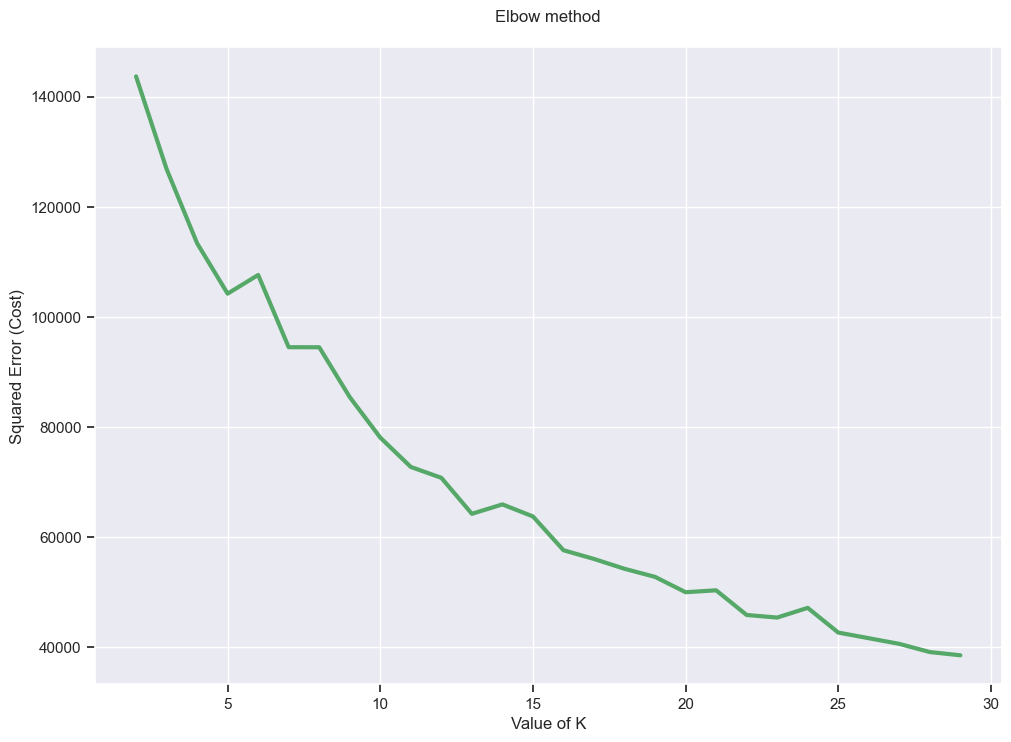

In [26]:
cost =[]
test_clusters = [i for i in range(2, 30)]
for i in test_clusters:
    #cls=KMeans(n_clusters=i,n_init=50,init='k-means++')
    cls = KMeans(n_clusters=i)
    cls.fit(X)
    cost.append(cls.inertia_)    


plt.plot(test_clusters, cost, color ='g', linewidth ='3')
plt.title("Elbow method\n")
plt.xlabel("Value of K")
plt.ylabel("Squared Error (Cost)")
#plt.axvline(x=nb_groupes_de_points, ymin=0, ymax=1, color="red")
plt.show()

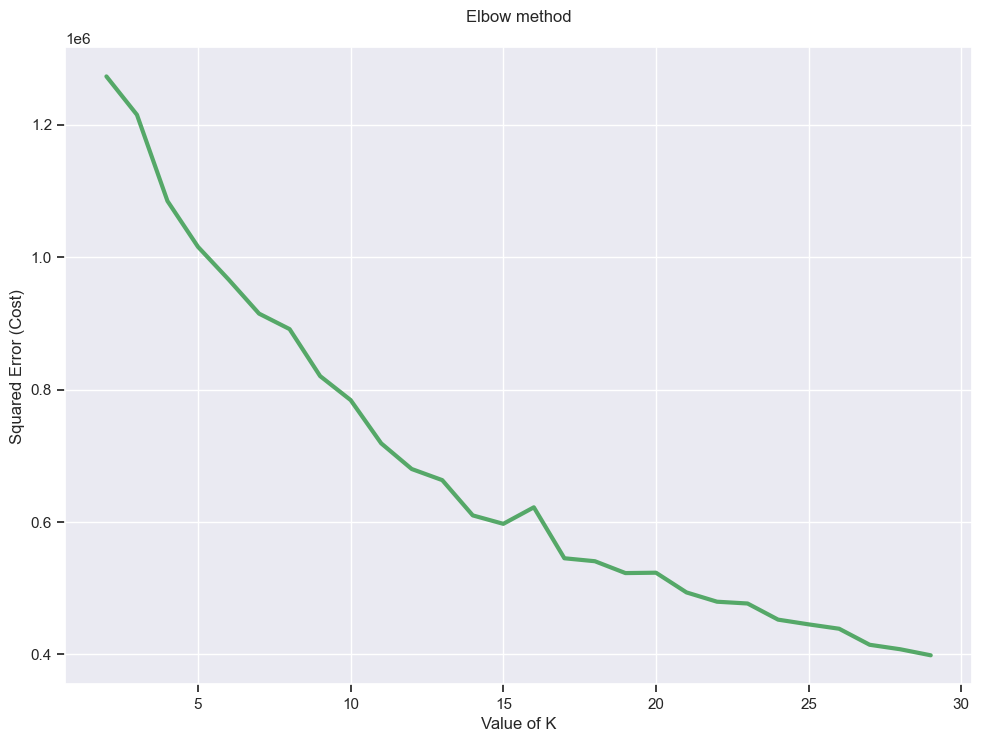

In [27]:
cost =[]
test_clusters = [i for i in range(2, 30)]
for i in test_clusters:
    #cls=KMeans(n_clusters=i,n_init=50,init='k-means++')
    cls = KMeans(n_clusters=i)
    cls.fit(X_std)
    cost.append(cls.inertia_)    


plt.plot(test_clusters, cost, color ='g', linewidth ='3')
plt.title("Elbow method\n")
plt.xlabel("Value of K")
plt.ylabel("Squared Error (Cost)")
#plt.axvline(x=nb_groupes_de_points, ymin=0, ymax=1, color="red")
plt.show()

In [28]:
# recherche nb optimum de clusters
## inertia = Sum of squared distances of samples to their closest cluster center

In [29]:
inertia = {}
dict_kmeans = {}
for k in range(1,25):
    print(k)
    kmeans = KMeans(n_clusters=k,
                   verbose=1,
                   random_state=0
                   ).fit(X_std)
    inertia[k] = kmeans.inertia_
    dict_kmeans[k] = kmeans

1
Initialization complete
Iteration 0, inertia 1787963.8770074504.
Iteration 1, inertia 1430984.9999999953.
Converged at iteration 1: strict convergence.
2
Initialization complete
Iteration 0, inertia 1615691.956931712.
Iteration 1, inertia 1294822.7642734707.
Iteration 2, inertia 1273069.5090099885.
Iteration 3, inertia 1272986.923694618.
Converged at iteration 3: center shift 1.3519491727189564e-05 within tolerance 0.00010000000000001086.
3
Initialization complete
Iteration 0, inertia 1498717.1250998331.
Iteration 1, inertia 1279595.9569842566.
Iteration 2, inertia 1224318.2997809243.
Iteration 3, inertia 1207191.588706234.
Iteration 4, inertia 1203422.7079302156.
Iteration 5, inertia 1201386.6552422848.
Iteration 6, inertia 1199726.4000989897.
Iteration 7, inertia 1198287.942540251.
Iteration 8, inertia 1196862.3483922526.
Iteration 9, inertia 1195078.7685215324.
Iteration 10, inertia 1192034.5461341606.
Iteration 11, inertia 1184351.7451697867.
Iteration 12, inertia 1155438.1830308

<AxesSubplot:title={'center':'Kmeans : Comparaison de la somme des inerties en fonction du nombre de clusters'}>

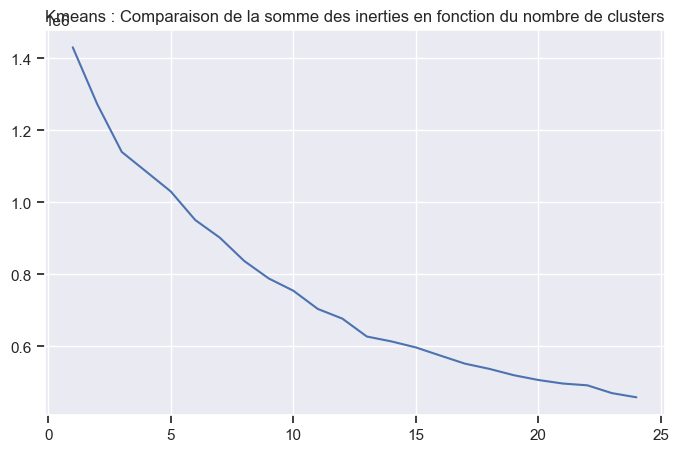

In [30]:
plt.figure(figsize=(8,5))
plt.title('Kmeans : Comparaison de la somme des inerties en fonction du nombre de clusters')
sns.lineplot(list(inertia.keys()),
             list(inertia.values())
            )


In [31]:
inertia = {}
dict_kmeans = {}

nb_boucles=3
max_clusters = 25

for k in range(1,nb_boucles+1):
    print('Boucle ',k)
    for i in range(1,max_clusters+1):
        kmeans = KMeans(n_clusters=i,
                       verbose=1,
                       #n_jobs=-1
                       ).fit(X_std)
        inertia[(k,i)] = kmeans.inertia_
        dict_kmeans[k,i] = kmeans

Boucle  1
Initialization complete
Iteration 0, inertia 1955094.4835350253.
Iteration 1, inertia 1430984.9999999953.
Converged at iteration 1: strict convergence.
Initialization complete
Iteration 0, inertia 1543456.3815359008.
Iteration 1, inertia 1309088.6789726245.
Iteration 2, inertia 1286357.5959953608.
Iteration 3, inertia 1281627.799549833.
Iteration 4, inertia 1281461.7298177881.
Iteration 5, inertia 1281448.7380611012.
Converged at iteration 5: center shift 8.317029826864767e-06 within tolerance 0.00010000000000001086.
Initialization complete
Iteration 0, inertia 1470240.4112344137.
Iteration 1, inertia 1253037.8331828748.
Iteration 2, inertia 1201454.2338070828.
Iteration 3, inertia 1186667.457209459.
Iteration 4, inertia 1161298.6164963623.
Iteration 5, inertia 1140392.837372032.
Iteration 6, inertia 1140360.1865777432.
Converged at iteration 6: center shift 1.1193899433935575e-05 within tolerance 0.00010000000000001086.
Initialization complete
Iteration 0, inertia 1208297.76

Iteration 0, inertia 73651.5312496192.
Iteration 1, inertia 50070.287229687456.
Iteration 2, inertia 49305.678456905356.
Iteration 3, inertia 49109.77759934149.
Iteration 4, inertia 48944.637102145454.
Iteration 5, inertia 48865.81359249083.
Iteration 6, inertia 48835.37589980018.
Iteration 7, inertia 48822.803439154784.
Iteration 8, inertia 48817.823951197905.
Iteration 9, inertia 48814.215123346745.
Iteration 10, inertia 48811.87093350178.
Iteration 11, inertia 48810.65912968383.
Iteration 12, inertia 48807.79453611134.
Iteration 13, inertia 48803.457251733445.
Iteration 14, inertia 48800.578059687294.
Iteration 15, inertia 48798.78350960177.
Iteration 16, inertia 48798.18043035808.
Iteration 17, inertia 48797.99923412284.
Converged at iteration 17: strict convergence.
Initialization complete
Iteration 0, inertia 65570.3187610987.
Iteration 1, inertia 48283.668617035306.
Iteration 2, inertia 46387.84940414285.
Iteration 3, inertia 45624.794169194334.
Iteration 4, inertia 45252.323626

Iteration 0, inertia 48739.5345115713.
Iteration 1, inertia 33603.45249295275.
Iteration 2, inertia 32702.653636989526.
Iteration 3, inertia 32430.070453546512.
Iteration 4, inertia 32371.03237867004.
Iteration 5, inertia 32338.921140043683.
Iteration 6, inertia 32265.21417173355.
Iteration 7, inertia 32095.195210593625.
Iteration 8, inertia 31951.152962478023.
Iteration 9, inertia 31922.922607876404.
Iteration 10, inertia 31914.060159862172.
Iteration 11, inertia 31912.589586121532.
Iteration 12, inertia 31911.57743016278.
Iteration 13, inertia 31911.150828198555.
Iteration 14, inertia 31910.934108574034.
Iteration 15, inertia 31910.760354887374.
Iteration 16, inertia 31910.4138141968.
Iteration 17, inertia 31910.350884798416.
Converged at iteration 17: strict convergence.
Initialization complete
Iteration 0, inertia 48656.41039456867.
Iteration 1, inertia 33959.310624687576.
Iteration 2, inertia 32715.257181660094.
Iteration 3, inertia 32339.01111591977.
Iteration 4, inertia 32146.43

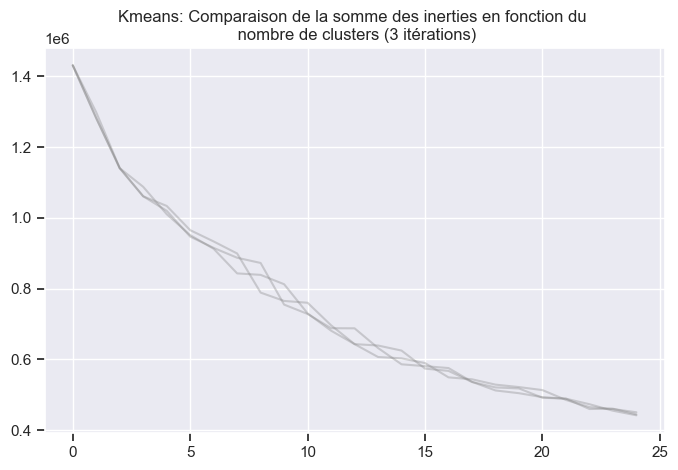

In [32]:
chaine = 'Kmeans: Comparaison de la somme des inerties en fonction du \n nombre de clusters (' + str(nb_boucles) + ' itérations)'
plt.figure(figsize=(8,5))
plt.title(chaine)
for i in range(0,nb_boucles):
    index_plot = [cluster+i*(max_clusters) for cluster in list(range(0,max_clusters))][0:max_clusters]
    sous_liste = [list(inertia.values())[index] for index in index_plot]
    sns.lineplot(list(range(0,max_clusters)),
                 sous_liste, alpha=1/nb_boucles, color='grey')

### coefficient de silhouette

In [33]:
silhouettes_kmeans = {}
max_clusters = 15
for i in range(2,max_clusters):
    sil_var = silhouette_score(
                                X = X_std,
                                labels= list(dict_kmeans[(1,i)].labels_))
    print(sil_var)
    #print(dict_kmeans[(1,i)].labels_)
    silhouettes_kmeans[i] = sil_var

0.17587836459129702
0.25252641345671695
0.2736551100394707
0.28182521337221283
0.2852108238755116
0.3095817265282911
0.20465230433317527
0.19406368884790826
0.32753454834014606
0.2824173538304274
0.29013860143318193
0.2356613773683326
0.26651016439801506


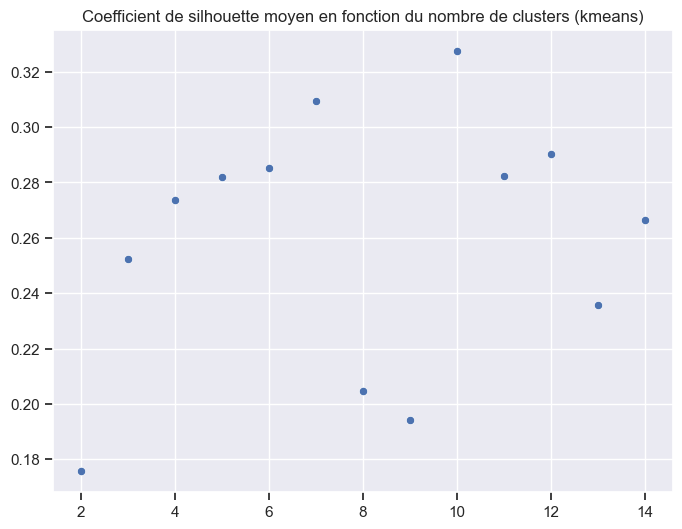

In [34]:
plt.figure(figsize=(8,6)),
plt.title('Coefficient de silhouette moyen en fonction du nombre de clusters (kmeans)')
sns.scatterplot(x = list(silhouettes_kmeans.keys()),
               y = list(silhouettes_kmeans.values()))
plt.show()

In [35]:
for key, value in silhouettes_kmeans.items():
    if value == max(silhouettes_kmeans.values()):
        print('le coefficient de silhouette est maximal pour {} clusters (score = {})'.format(key, value))
        nb_clusters = key

le coefficient de silhouette est maximal pour 10 clusters (score = 0.32753454834014606)


In [36]:
nb_clusters

10

### Model

In [37]:
kmeans = KMeans(n_clusters=3, 
                verbose=1, 
                random_state=0,
               #n_jobs=-1
               ).fit(X_std)

Initialization complete
Iteration 0, inertia 1498717.1250998331.
Iteration 1, inertia 1279595.9569842566.
Iteration 2, inertia 1224318.2997809243.
Iteration 3, inertia 1207191.588706234.
Iteration 4, inertia 1203422.7079302156.
Iteration 5, inertia 1201386.6552422848.
Iteration 6, inertia 1199726.40009899.
Iteration 7, inertia 1198287.942540251.
Iteration 8, inertia 1196862.3483922526.
Iteration 9, inertia 1195078.7685215324.
Iteration 10, inertia 1192034.5461341606.
Iteration 11, inertia 1184351.7451697867.
Iteration 12, inertia 1155438.1830308675.
Iteration 13, inertia 1140746.2498912467.
Iteration 14, inertia 1140531.4718180818.
Iteration 15, inertia 1140363.9616132516.
Iteration 16, inertia 1140359.8842862195.
Converged at iteration 16: center shift 6.992990937132716e-06 within tolerance 0.00010000000000001086.


In [38]:
kmeans.labels_

array([2, 0, 2, ..., 1, 1, 0])

In [39]:
##wcss stands for within cluster sum of squares


#wcss={}

#for k in range(2,15):
#    km = KMeans(n_clusters=k, init='k-means++', max_iter=1000 , random_state=20)
#    km = km.fit(X)
#    wcss[k] = silhouette_score(X, km.labels_)
    
##Plot graph for the wcss values and the number of clusters

#sns.pointplot(x=list(wcss.keys()), y=list(wcss.values()))
#plt.xlabel('Number of clusters K')
#plt.ylabel('Sum of square distances')
#plt.title('Elbow method for optimal K')
#plt.show()

In [40]:
# score de silhouette
#  sklearn.metrics.silhouette_score(X, labels, *, metric='euclidean', sample_size=None, random_state=None, **kwds)[source]

## T-SNE

In [41]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=0)

In [ ]:
tsne_result = tsne.fit_transform(X_std)

In [ ]:
tsne_result.shape

In [ ]:
# Représentation via T-SNE
plt.figure(figsize=(8,8))
plt.title('Représentation de la séparation des données du DBSCAN via T-SNE')
sns.scatterplot(tsne_result[:,0], tsne_result[:,1])

# DBscan

In [ ]:
dbs = DBSCAN(eps = 1, 
             min_samples=5,
               n_jobs=-1
            ).fit(X_std.copy())

In [ ]:
dbs.labels_

In [ ]:
# Représentation via T-SNE
plt.figure(figsize=(8,8))
plt.title('Représentation de la séparation des données du DBSCAN via T-SNE')
sns.scatterplot(tsne_result[:,0], tsne_result[:,1], dbs.labels_)

In [ ]:
# https://medium.com/@mohantysandip/a-step-by-step-approach-to-solve-dbscan-algorithms-by-tuning-its-hyper-parameters-93e693a91289
# silhouette to eps distance

# silhouette score gives the avg value for all the samples.
# this gives a perspective into the density and separation of the formed clusters

#range_eps = np.arange(0.1, 1.1, 0.1)
range_eps = np.arange(1, 10, 1)
range_eps

In [ ]:
dict = {
    "eps_value" :[]
    ,"silhouette_avg" :[]
    }

for i in range_eps:
    #print("eps value is " +str(i))
    db= DBSCAN(eps=i, min_samples=5, n_jobs=-1).fit(X_std)
    core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
    core_samples_mask[db.core_sample_indices_] = True
    labels = db.labels_
    #print(set(labels))
    silhouette_avg = silhouette_score(X_std, labels)
    dict["eps_value"].append(i)
    dict["silhouette_avg"].append(silhouette_avg)
    #print("For eps value = "+str(i), labels,
    #      "The average silhouette_score is : ", silhouette_avg)

eps_df = pd.DataFrame.from_dict(dict)
eps_df.sort_values(by="silhouette_avg", ascending=False)

In [ ]:
eps_max_silhouette = float(eps_df.sort_values(by="silhouette_avg", ascending=False).head(1)['eps_value'])
eps_max_silhouette

In [ ]:
# find the 'min_samples' hyper parameter through right cluster formation method

min_samples = np.arange(1, 11, 1)
min_samples

In [ ]:
dict2 = {
    "min_sample_value" :[]
    ,"nb_clusters" :[]
    }

for i in min_samples:
    db= DBSCAN(eps=eps_max_silhouette, min_samples=i, n_jobs=-1).fit(X_enc)
    core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
    core_samples_mask[db.core_sample_indices_] = True
    # Ignoring the label '-1' as its for the outliers
    labels = set([label for label in db.labels_ if label >=0])
    dict2["min_sample_value"].append(i)
    dict2["nb_clusters"].append(str(len(set(labels))))
    #print("For eps value = "+str(i), labels,
    #      "The average silhouette_score is : ", silhouette_avg)

min_samples_df = pd.DataFrame.from_dict(dict2)
min_samples_df.sort_values(by="nb_clusters", ascending=False) 

In [ ]:
### compute DBSCAN with new values :
dbs_2 = DBSCAN(eps= 2, 
             min_samples= 7,
               n_jobs= -1
            ).fit(X_enc.copy())
dbs_2.labels_

In [ ]:
# Représentation via T-SNE
plt.figure(figsize=(8,8))
plt.title('Représentation de la séparation des données du DBSCAN via T-SNE')
sns.scatterplot(tsne_result[:,0], tsne_result[:,1], dbs_2.labels_)

## SMOTE-NC

In [ ]:
# https://medium.com/analytics-vidhya/smote-nc-in-ml-categorization-models-fo-imbalanced-datasets-8adbdcf08c25

### Clustering hiérarchique

In [ ]:
nb_clusters_agg = nb_clusters

In [ ]:
cah = AgglomerativeClustering(n_clusters = nb_clusters_agg
                             ).fit(X.copy())


In [ ]:
graph = pd.DataFrame(data = [T[:,0], T[:,1], dict_kmeans[(1,11)].labels_]).T
graph.columns = ['X', 'Y', 'label_kmeans']

In [ ]:
graph['x_pca'] = x_show
graph['y_pca'] = y_show
graph['z_pca'] = z_show

In [ ]:
graph

In [ ]:
plt.figure(figsize=(10,10))
plt.title('Représentation de la séparation des données du CAH via T-SNE')
sns.scatterplot(graph['X'], 
                graph['Y'], 
                hue = cah.labels_, 
                legend='full',
               palette=sns.color_palette("hls",nb_clusters_agg))
plt.legend(loc='upper left', labels=graph['label_kmeans'].unique())
plt.show()

In [ ]:
## ne pas utiliser PCA (permet de voir cassure) => focus TSNE (x y z)
## dbscan sur 3
# visualisation : tsne + labels/couleurs, scatterplot
# /!\ scaling / encoding données : dans la préparation des données, modelisation = modeles uniquement

In [ ]:
# ajouter features
# chercher meilleur parametrage 
# pour kmeans et pour dbscan
# /!\ responsable pédagogique